In [1]:
# [setup]
import os
import subprocess
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

# --- File paths ---
# Desktop: threshold-aligned cap-426 build (threshold=-0.05 matching April's package default)
DESKTOP_NO_IRAN_PATH = "data-official/2026-06/desktop_cps0.15983_thresh050_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-26.ld-D.raw.parquet"
DESKTOP_PLUS_IRAN_PATH = "data-official/2026-06/desktop_cps0.15983_thresh050_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-26.ld-D.raw.plus_iran.parquet"
# Mobile: marketing-lift baked in (.adj-m.) — the Fenix Android paid campaign launched 2026-04-06
MOBILE_NO_IRAN_PATH = "data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-26.gm-D.adj-m.parquet"
MOBILE_PLUS_IRAN_PATH = "data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-26.gm-D.adj-m.plus_iran.parquet"
# Prior (April) forecast — threshold-matched dir so April uses the same threshold methodology
PREV_FORECAST_DESKTOP_PLUS_IRAN_PATH = "data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.ld-D.raw.plus_iran.parquet"
PREV_FORECAST_DESKTOP_NO_IRAN_PATH = "data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet"
PREV_FORECAST_MOBILE_PLUS_IRAN_PATH = "data-official/2026-04/mobile_cps0.02_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.gm-D.raw.plus_iran.parquet"
PREV_FORECAST_MOBILE_NO_IRAN_PATH = "data-official/2026-04/mobile_cps0.02_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet"
ADJUSTMENTS_DIR = "data-official/2026-06/adjustments"
# April's own adjustments — applied to the prior (N-1) series so the comparison
# is between "April shipped as-is" and "June shipping with its own headwind".
PREV_ADJUSTMENTS_DIR = "data-official/2026-04/adjustments"

# --- Date constants ---
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-05-26")
PREV_FORECAST_START = pd.Timestamp("2026-04-01")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")

# BQ query lookback — need 28 days before DISPLAY_START for MA
BQ_START = "2025-12-04"

# Anchor execution at git root so relative paths work regardless of notebook location
os.chdir(subprocess.run(['git', 'rev-parse', '--show-toplevel'], capture_output=True, text=True).stdout.strip())


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [helpers]
import sys

# Single source of truth for the seam-smoothed forecast MA: import the variance-matched
# display_ma (and its reconstruct_matched_daily helper) from the canonical exporter so the
# notebook's forecast curves match the exported CSVs/PNGs exactly. The actuals series keep
# the plain daily_to_28ma defined below. See research/ma-seam-turbulence/ for the diagnosis.
sys.path.insert(0, "data-official/2026-06")
from export_canonical_curves import display_ma, reconstruct_matched_daily  # noqa: E402


def render_adjustment(spec, date_index):
    """Convert a single adjustment spec to net DAU Series for desktop and mobile."""
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    mobile = pd.Series(0.0, index=idx)

    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
        mobile[:] = spec.get("mobile_dau", 0) * elapsed / total_days

    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        mask = (idx >= start) & (idx <= end)
        desktop[mask] = spec.get("desktop_dau", 0)
        mobile[mask] = spec.get("mobile_dau", 0)

    elif spec["type"] == "daily_series":
        for date_str, values in spec["series"].items():
            date = pd.Timestamp(date_str)
            if date in idx:
                loc = idx.get_loc(date)
                desktop.iloc[loc] = values.get("desktop_dau", 0)
                mobile.iloc[loc] = values.get("mobile_dau", 0)

    return {"desktop": desktop, "mobile": mobile}


def load_adjustments(adjustments_dir, date_index):
    """Sum all adjustment components in a directory into net desktop/mobile DAU series."""
    idx = pd.DatetimeIndex(date_index)
    desktop_total = pd.Series(0.0, index=idx)
    mobile_total = pd.Series(0.0, index=idx)
    for path in sorted(glob.glob(f"{adjustments_dir}/*.json")):
        with open(path) as f:
            spec = json.load(f)
        rendered = render_adjustment(spec, idx)
        desktop_total += rendered["desktop"]
        mobile_total += rendered["mobile"]
    return {"desktop": desktop_total, "mobile": mobile_total}


def apply_net_adjustment(ma_series, net_adjustments, platform, forecast_start=None):
    """Apply net adjustment to a 28-day MA series, starting at forecast_start.

    Uses FORECAST_START by default. Pass a different date for prior forecasts whose
    predicted data begins earlier (e.g. PREV_FORECAST_START for the N-1 comparison).
    """
    if forecast_start is None:
        forecast_start = FORECAST_START
    result = ma_series.copy()
    forecast_mask = result.index >= forecast_start
    # Reindex to ma_series dates — desktop and mobile have different date ranges
    adj = net_adjustments[platform].reindex(result.index, fill_value=0.0)
    result[forecast_mask] += adj[forecast_mask]
    return result


def load_all_level_dau(path, data_source, segment_filter, app_filter):
    """Load a forecast parquet, return ALL-level daily DAU with data_type."""
    df = pd.read_parquet(path)
    mask = (
        (df["country"] == "ALL")
        & (df["segment"] == segment_filter)
        & (df["data_source"] == data_source)
        & (df["app_name"] == app_filter)
    )
    result = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values("target_date").reset_index(drop=True)


def daily_to_28ma(dates, values):
    """Compute 28-day moving average. Returns a date-indexed Series."""
    s = pd.Series(values.values, index=pd.to_datetime(dates.values))
    return s.sort_index().rolling(28).mean()


In [3]:
# [load-parquets]
desktop_no_iran_raw = load_all_level_dau(
    DESKTOP_NO_IRAN_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop"
)
desktop_plus_iran_raw = load_all_level_dau(
    DESKTOP_PLUS_IRAN_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop"
)
mobile_no_iran_raw = load_all_level_dau(
    MOBILE_NO_IRAN_PATH, "glean_mobile", "{}", "ALL MOBILE"
)
mobile_plus_iran_raw = load_all_level_dau(
    MOBILE_PLUS_IRAN_PATH, "glean_mobile", "{}", "ALL MOBILE"
)

for label, df in [
    ("Desktop no-Iran", desktop_no_iran_raw),
    ("Desktop plus-Iran", desktop_plus_iran_raw),
    ("Mobile no-Iran", mobile_no_iran_raw),
    ("Mobile plus-Iran", mobile_plus_iran_raw),
]:
    print(f"{label}: {len(df)} rows, {df['target_date'].min().date()} to {df['target_date'].max().date()}")

Desktop no-Iran: 2922 rows, 2020-01-01 to 2027-12-31
Desktop plus-Iran: 2922 rows, 2020-01-01 to 2027-12-31
Mobile no-Iran: 2557 rows, 2020-12-31 to 2027-12-31
Mobile plus-Iran: 2557 rows, 2020-12-31 to 2027-12-31


In [4]:
# [load-prev-forecast]
prev_desktop_plus_iran_raw = load_all_level_dau(PREV_FORECAST_DESKTOP_PLUS_IRAN_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop")
prev_desktop_no_iran_raw = load_all_level_dau(PREV_FORECAST_DESKTOP_NO_IRAN_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop")
prev_mobile_plus_iran_raw = load_all_level_dau(PREV_FORECAST_MOBILE_PLUS_IRAN_PATH, "glean_mobile", "{}", "ALL MOBILE")
prev_mobile_no_iran_raw = load_all_level_dau(PREV_FORECAST_MOBILE_NO_IRAN_PATH, "glean_mobile", "{}", "ALL MOBILE")
print(f"Prior desktop +Iran: {len(prev_desktop_plus_iran_raw)} rows | no-Iran: {len(prev_desktop_no_iran_raw)} rows")
print(f"Prior mobile  +Iran: {len(prev_mobile_plus_iran_raw)} rows | no-Iran: {len(prev_mobile_no_iran_raw)} rows")


Prior desktop +Iran: 2922 rows | no-Iran: 2922 rows
Prior mobile  +Iran: 2557 rows | no-Iran: 2557 rows


In [5]:
# [bq-actuals]
# Actuals cutoff = CURRENT_DATE("America/Los_Angeles") - 2 because Glean
# mobile's most-recent landed day can be partial (one ~500k DAU point poisons
# the trailing MA28 endpoint by ~1M). The LA-time clamp matters: plain
# CURRENT_DATE() returns UTC, so after ~5pm PDT it bumps to tomorrow and -2
# lands ON the still-partial day.
import sys, time

client = bigquery.Client(project="moz-fx-data-bq-data-science")

queries = {
    "desktop_with_iran": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
    "desktop_no_iran": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
          AND country != 'IR'
        GROUP BY submission_date ORDER BY 1
    """,
    "mobile_with_iran": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
    "mobile_no_iran": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
          AND country != 'IR'
        GROUP BY submission_date ORDER BY 1
    """,
}

bq_actuals = {}
t0 = time.time()
for i, (name, sql) in enumerate(queries.items(), 1):
    sys.stdout.write(f"[{i}/{len(queries)}] {name}...")
    sys.stdout.flush()
    df = client.query(sql).to_dataframe()
    df["date"] = pd.to_datetime(df["date"])
    bq_actuals[name] = df
    sys.stdout.write(f" {len(df)} rows ({time.time() - t0:.1f}s elapsed)\n")
    sys.stdout.flush()

print("Done.")


[1/4] desktop_with_iran... 179 rows (16.9s elapsed)
[2/4] desktop_no_iran... 179 rows (32.0s elapsed)
[3/4] mobile_with_iran... 179 rows (40.2s elapsed)
[4/4] mobile_no_iran... 179 rows (48.5s elapsed)
Done.


In [6]:
# [compute-series]
# 28-day MAs from raw parquet (no adjustments yet). Forecast curves use the variance-matched
# display_ma (seam-smoothed across the actuals->forecast transition); actuals use the plain
# daily_to_28ma. display_ma is byte-identical to daily_to_28ma from forecast-start +27d onward
# (incl. the Dec-15 headline), so only the first 27-day seam transition differs.
desktop_no_iran_ma_raw = display_ma(desktop_no_iran_raw["target_date"], desktop_no_iran_raw["dau"], FORECAST_START)
desktop_plus_iran_ma_raw = display_ma(desktop_plus_iran_raw["target_date"], desktop_plus_iran_raw["dau"], FORECAST_START)
mobile_no_iran_ma_raw = display_ma(mobile_no_iran_raw["target_date"], mobile_no_iran_raw["dau"], FORECAST_START)
mobile_plus_iran_ma_raw = display_ma(mobile_plus_iran_raw["target_date"], mobile_plus_iran_raw["dau"], FORECAST_START)

# Two adjustment sets — current (June) and prior (April). Each forecast carries
# its own headwind because what's compared is "April shipped numbers vs June
# proposed shipping numbers", not a model-on-model apples-to-apples diff.
net_adjustments = load_adjustments(ADJUSTMENTS_DIR, desktop_no_iran_ma_raw.index)
prev_net_adjustments = load_adjustments(PREV_ADJUSTMENTS_DIR, desktop_no_iran_ma_raw.index)

desktop_no_iran_ma = apply_net_adjustment(desktop_no_iran_ma_raw, net_adjustments, "desktop")
desktop_plus_iran_ma = apply_net_adjustment(desktop_plus_iran_ma_raw, net_adjustments, "desktop")
mobile_no_iran_ma = apply_net_adjustment(mobile_no_iran_ma_raw, net_adjustments, "mobile")
mobile_plus_iran_ma = apply_net_adjustment(mobile_plus_iran_ma_raw, net_adjustments, "mobile")

# 28-day MAs from BQ actuals
desktop_actual_all_ma = daily_to_28ma(bq_actuals["desktop_with_iran"]["date"], bq_actuals["desktop_with_iran"]["dau"])
desktop_actual_no_iran_ma = daily_to_28ma(bq_actuals["desktop_no_iran"]["date"], bq_actuals["desktop_no_iran"]["dau"])
mobile_actual_all_ma = daily_to_28ma(bq_actuals["mobile_with_iran"]["date"], bq_actuals["mobile_with_iran"]["dau"])
mobile_actual_no_iran_ma = daily_to_28ma(bq_actuals["mobile_no_iran"]["date"], bq_actuals["mobile_no_iran"]["dau"])

# Prior forecast (N-1) 28-day MA — uses April's own headwind anchor (not June's),
# so the comparison is "as-shipped" rather than "same headwind to both". Forecast
# start is PREV_FORECAST_START (2026-04-01) so the seam-smoothing and masking align
# with April's delivered forecast horizon.
prev_desktop_plus_iran_ma = apply_net_adjustment(
    display_ma(prev_desktop_plus_iran_raw["target_date"], prev_desktop_plus_iran_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "desktop", forecast_start=PREV_FORECAST_START,
)
prev_desktop_no_iran_ma = apply_net_adjustment(
    display_ma(prev_desktop_no_iran_raw["target_date"], prev_desktop_no_iran_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "desktop", forecast_start=PREV_FORECAST_START,
)
prev_mobile_plus_iran_ma = apply_net_adjustment(
    display_ma(prev_mobile_plus_iran_raw["target_date"], prev_mobile_plus_iran_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "mobile", forecast_start=PREV_FORECAST_START,
)
prev_mobile_no_iran_ma = apply_net_adjustment(
    display_ma(prev_mobile_no_iran_raw["target_date"], prev_mobile_no_iran_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "mobile", forecast_start=PREV_FORECAST_START,
)

# Verify net adjustment at key dates
print(f"Net adjustment at {MEASUREMENT_DATE.date()} (current — June):")
for platform in ["desktop", "mobile"]:
    val = net_adjustments[platform].get(MEASUREMENT_DATE, float("nan"))
    print(f"  {platform}: {val:+,.0f} DAU")

print(f"\nNet adjustment at {MEASUREMENT_DATE.date()} (prior — April):")
for platform in ["desktop", "mobile"]:
    val = prev_net_adjustments[platform].get(MEASUREMENT_DATE, float("nan"))
    print(f"  {platform}: {val:+,.0f} DAU")

print(f"\nPer-component breakdown at {MEASUREMENT_DATE.date()} (June):")
for path in sorted(glob.glob(f"{ADJUSTMENTS_DIR}/*.json")):
    with open(path) as f:
        spec = json.load(f)
    rendered = render_adjustment(spec, [MEASUREMENT_DATE])
    name = path.split("/")[-1].replace(".json", "")
    d_val = rendered["desktop"].iloc[0]
    m_val = rendered["mobile"].iloc[0]
    print(f"  {name}: desktop {d_val:+,.0f}, mobile {m_val:+,.0f}")

print(f"\nPer-component breakdown at {MEASUREMENT_DATE.date()} (April):")
for path in sorted(glob.glob(f"{PREV_ADJUSTMENTS_DIR}/*.json")):
    with open(path) as f:
        spec = json.load(f)
    rendered = render_adjustment(spec, [MEASUREMENT_DATE])
    name = path.split("/")[-1].replace(".json", "")
    d_val = rendered["desktop"].iloc[0]
    m_val = rendered["mobile"].iloc[0]
    print(f"  {name}: desktop {d_val:+,.0f}, mobile {m_val:+,.0f}")


Net adjustment at 2026-12-15 (current — June):
  desktop: -1,420,000 DAU
  mobile: -27,162 DAU

Net adjustment at 2026-12-15 (prior — April):
  desktop: -1,497,870 DAU
  mobile: -27,162 DAU

Per-component breakdown at 2026-12-15 (June):
  headwind: desktop -1,420,000, mobile -27,162

Per-component breakdown at 2026-12-15 (April):
  headwind: desktop -1,497,870, mobile -27,162


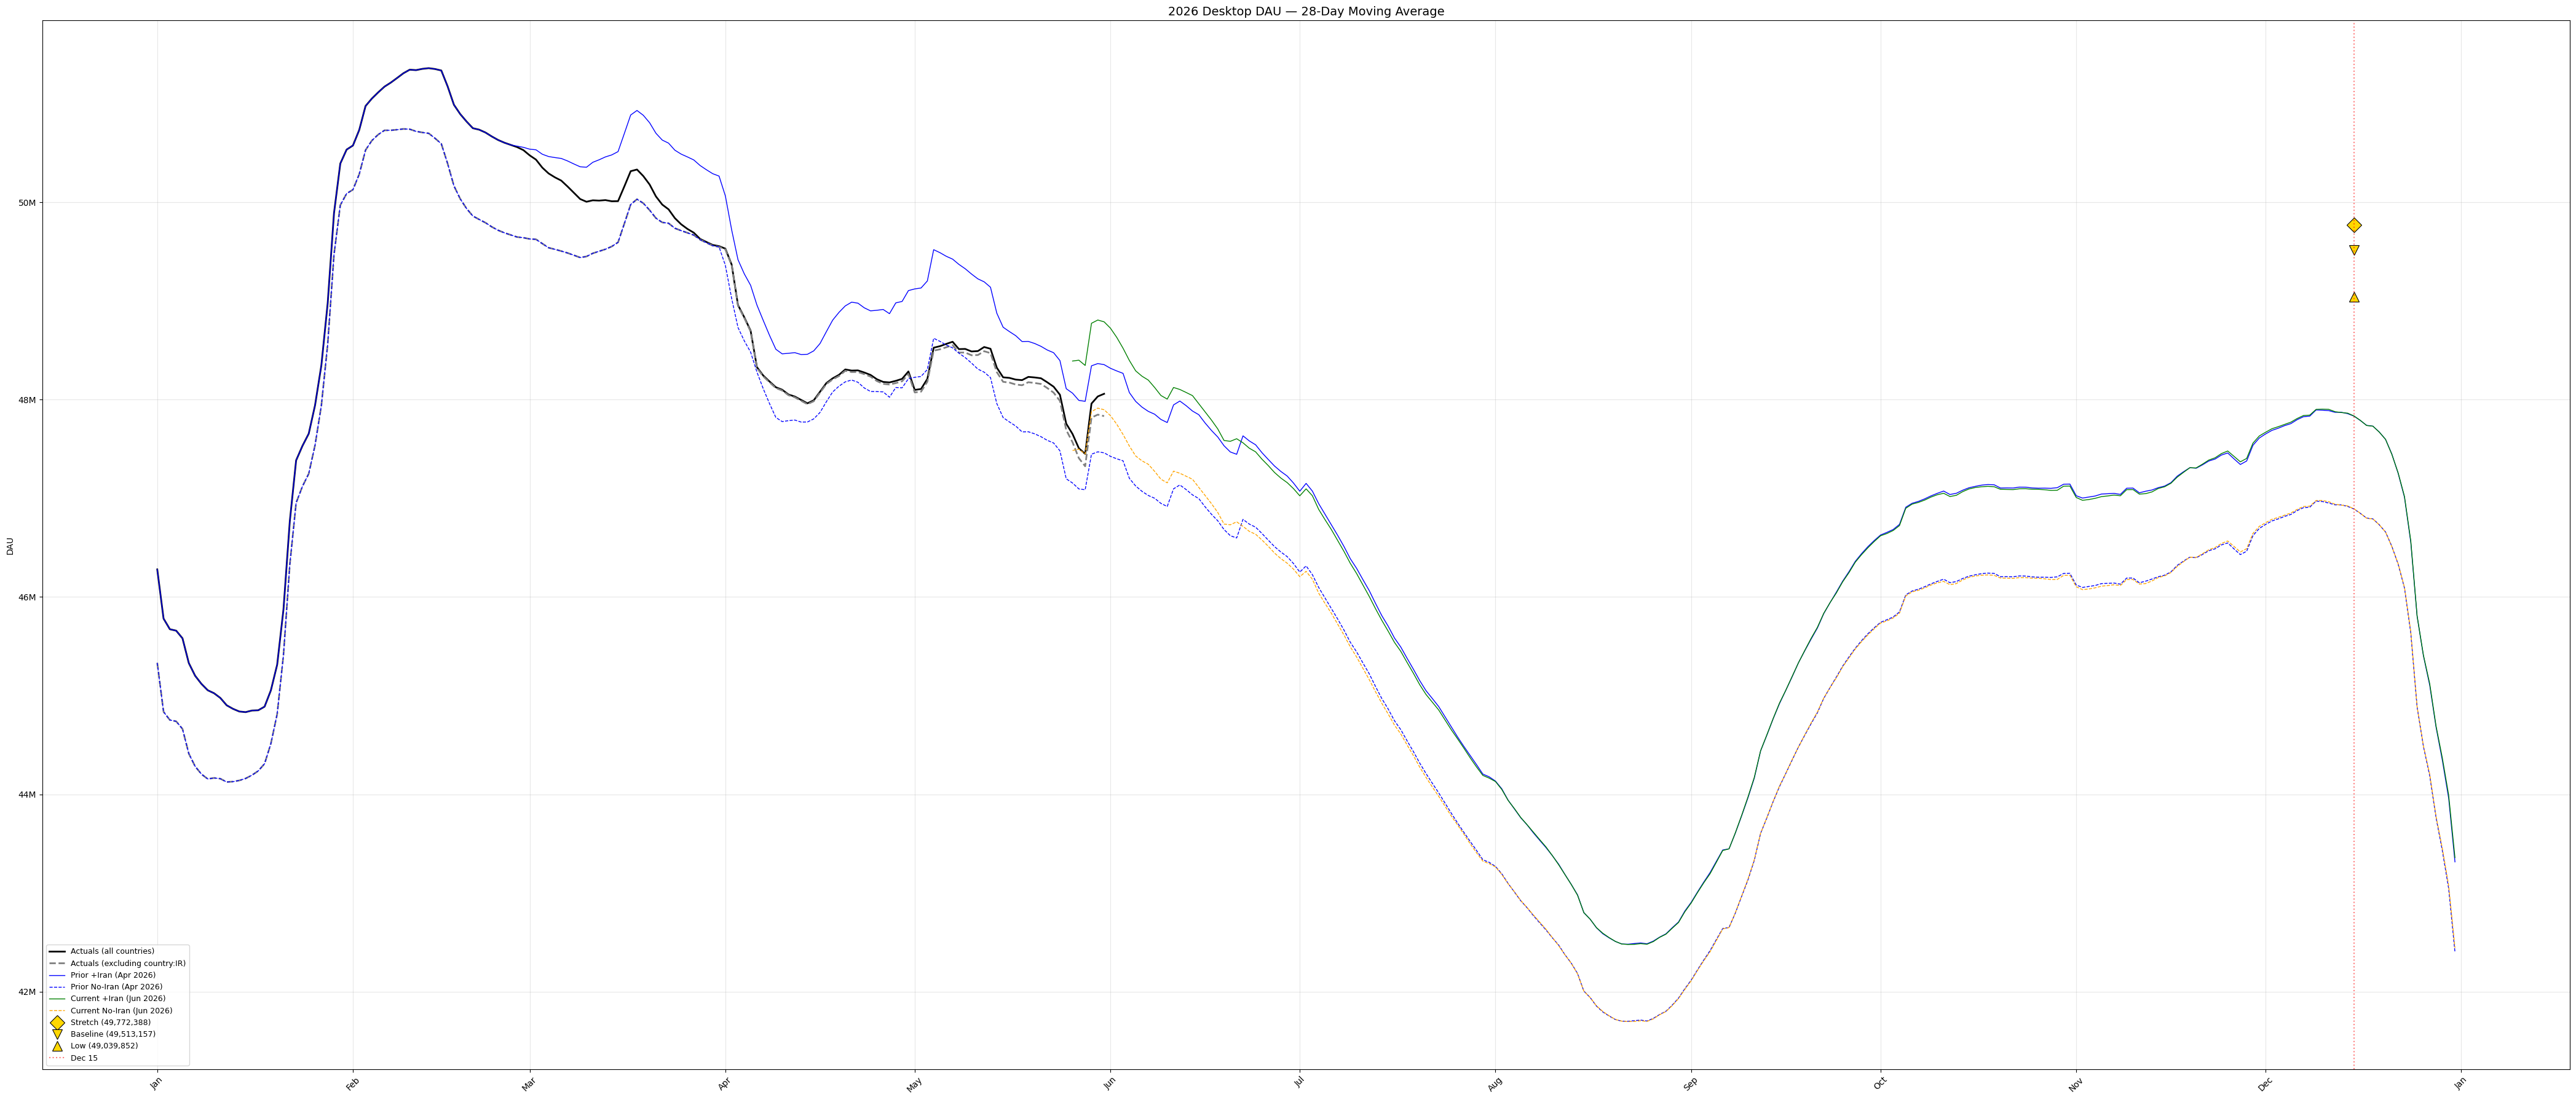

In [25]:
# [plot-desktop]
def clip_display(s):
    """Filter a date-indexed series to the display window."""
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()

def clip_forecast_only(s):
    """Filter to forecast portion only within display window."""
    return s[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)].dropna()

def millions_formatter(x, pos):
    return f"{x / 1e6:.0f}M"

# Stakeholder Dec-15 benchmarks
STAKEHOLDER_DESKTOP_LOW = 49_039_852
STAKEHOLDER_DESKTOP_BASELINE = 49_513_157
STAKEHOLDER_DESKTOP_STRETCH = 49_772_388

def render_desktop_plot(*, show_april: bool, title: str):
    fig, ax = plt.subplots(figsize=(42, 18))
    # Actuals (bold)
    ax.plot(clip_display(desktop_actual_all_ma), label="Actuals (all countries)",
            color="black", linewidth=2)
    ax.plot(clip_display(desktop_actual_no_iran_ma), label="Actuals (excluding country:IR)",
            color="gray", linewidth=2, linestyle="--")
    # April forecasts (blue) — only when show_april
    if show_april:
        ax.plot(clip_display(prev_desktop_plus_iran_ma), label="Prior +Iran (Apr 2026)",
                color="blue", linewidth=1)
        ax.plot(clip_display(prev_desktop_no_iran_ma), label="Prior No-Iran (Apr 2026)",
                color="blue", linewidth=1, linestyle="--")
    # June (current) forecasts
    ax.plot(clip_forecast_only(desktop_plus_iran_ma), label="Current +Iran (Jun 2026)",
            color="green", linewidth=1)
    ax.plot(clip_forecast_only(desktop_no_iran_ma), label="Current No-Iran (Jun 2026)",
            color="orange", linewidth=1, linestyle="--")
    # Stakeholder markers — stretch=diamond, base=down-triangle, low=up-triangle
    # (matches research/marketing-lift/v2-real-data/05_v2_trial_forecast_diagnostic.ipynb)
    for value, marker, label in [
        (STAKEHOLDER_DESKTOP_STRETCH, "D", "Stretch"),
        (STAKEHOLDER_DESKTOP_BASELINE, "v", "Baseline"),
        (STAKEHOLDER_DESKTOP_LOW, "^", "Low"),
    ]:
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
                markersize=12, markeredgecolor="black", markeredgewidth=0.8,
                linestyle="None", label=f"{label} ({value:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower left", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

render_desktop_plot(show_april=True,
                    title="2026 Desktop DAU — 28-Day Moving Average")


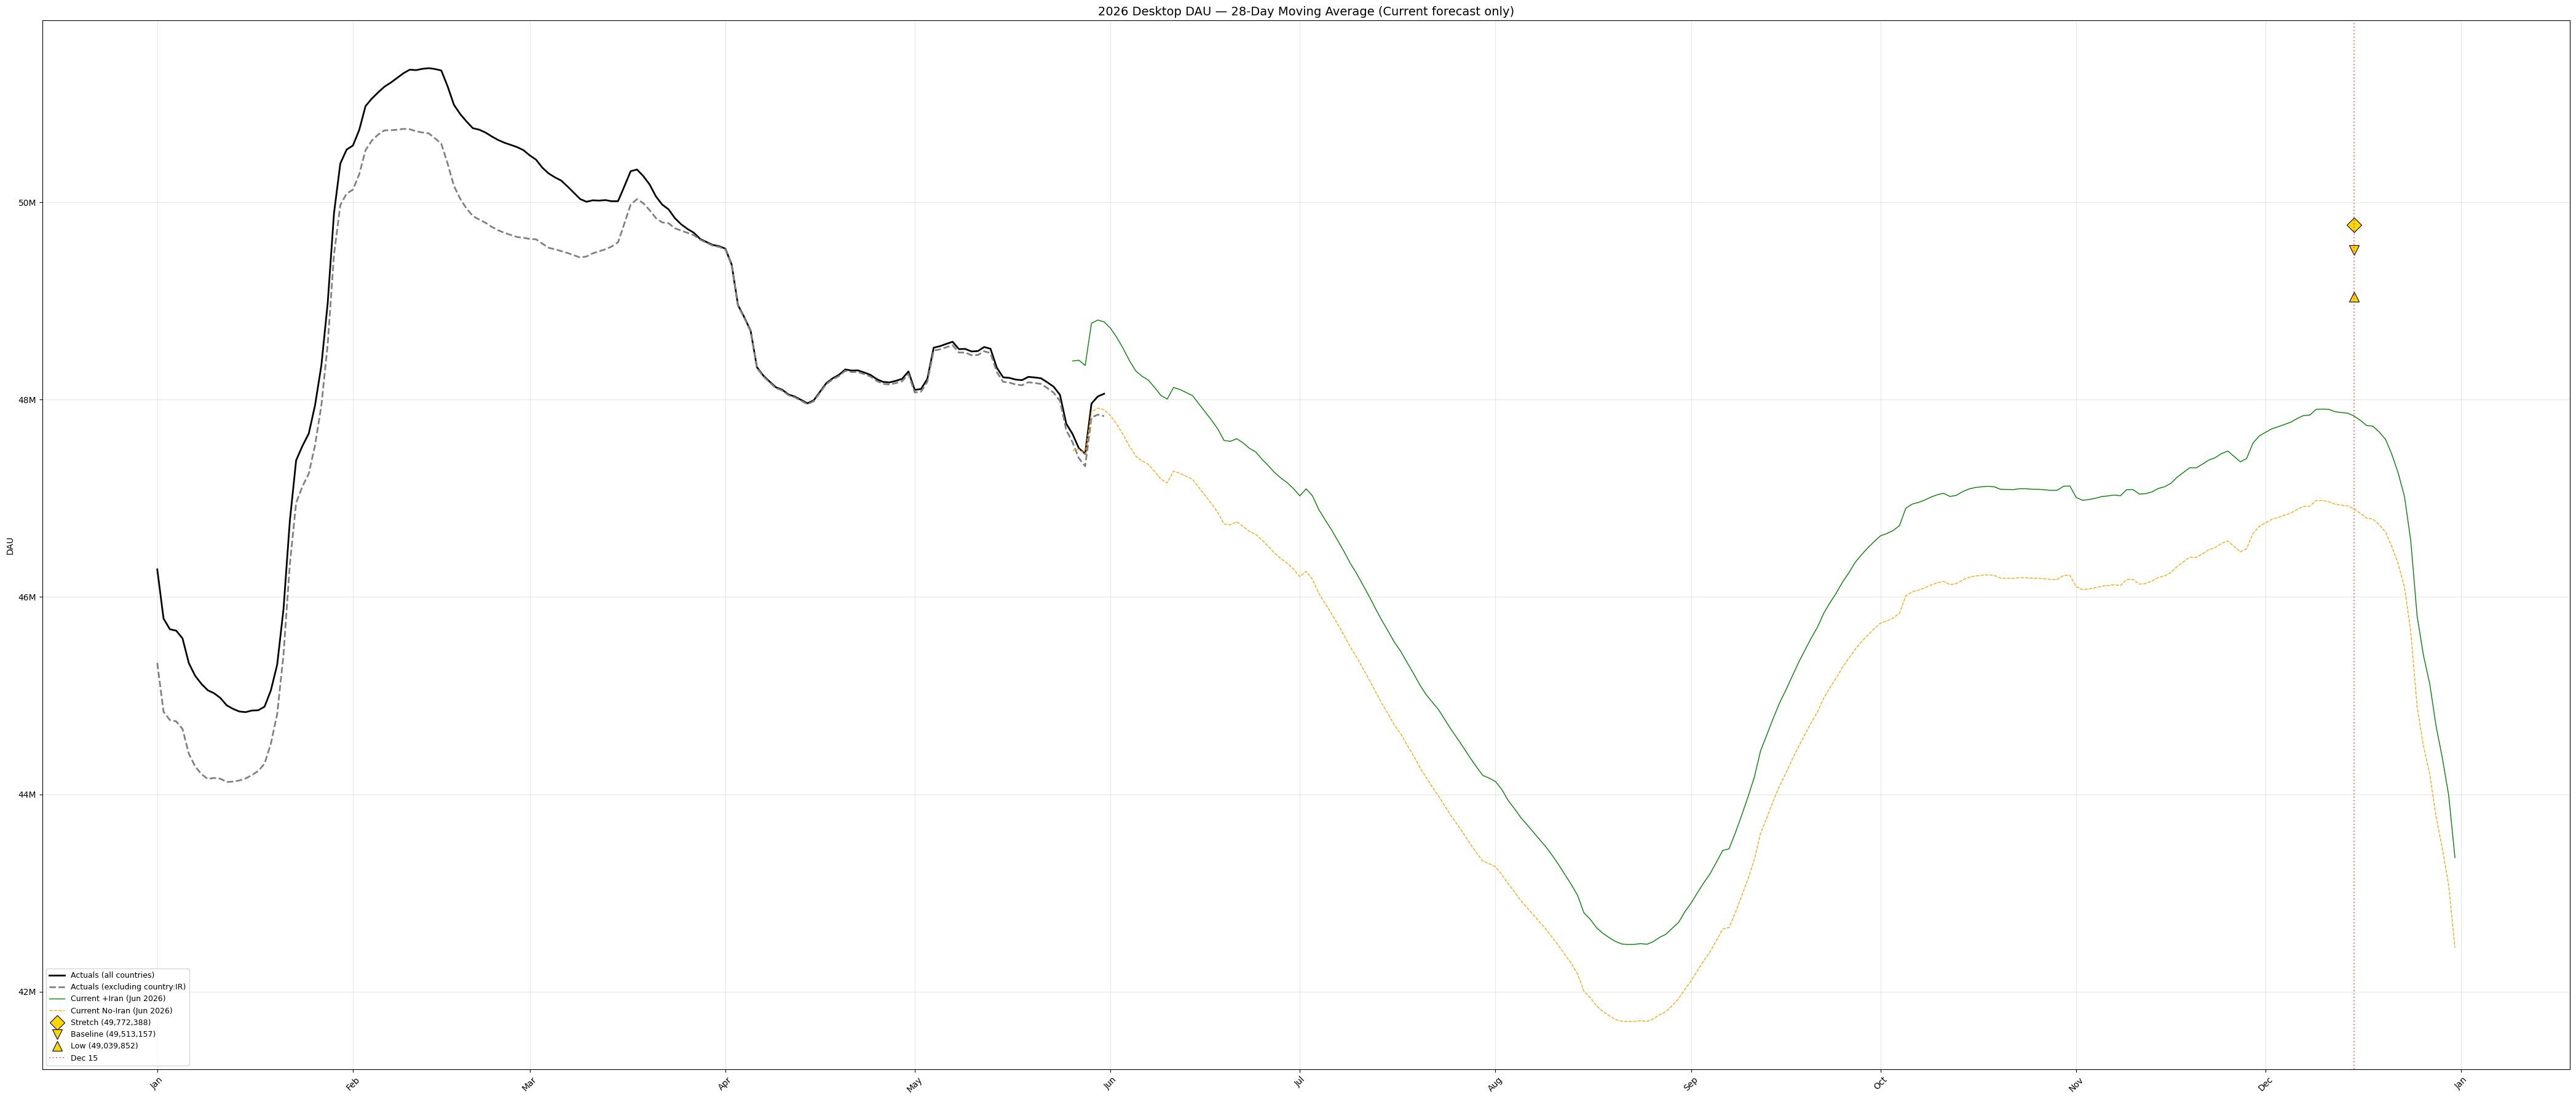

In [26]:
# [plot-desktop-no-april]
render_desktop_plot(show_april=False,
                    title="2026 Desktop DAU — 28-Day Moving Average (Current forecast only)")


In [27]:
# [desktop-dec15]
desktop_series = {
    "Actuals (all countries)": desktop_actual_all_ma,
    "Actuals (excl IR)": desktop_actual_no_iran_ma,
    "Prior +Iran (Apr 2026)": prev_desktop_plus_iran_ma,
    "Prior No-Iran (Apr 2026)": prev_desktop_no_iran_ma,
    "Current +Iran (Jun 2026)": desktop_plus_iran_ma,
    "Current No-Iran (Jun 2026)": desktop_no_iran_ma,
}

header = f"{'Series':<28s} {'Dec 15 28-day MA':>18s}"
print(header)
print("-" * len(header))
for name, s in desktop_series.items():
    val = s.get(MEASUREMENT_DATE, np.nan)
    val_str = f"{val:>15,.0f}" if pd.notna(val) else f"{'N/A':>15s}"
    print(f"{name:<28s} {val_str:>18s}")


Series                         Dec 15 28-day MA
-----------------------------------------------
Actuals (all countries)                     N/A
Actuals (excl IR)                           N/A
Prior +Iran (Apr 2026)               47,832,386
Prior No-Iran (Apr 2026)             46,891,136
Current +Iran (Jun 2026)             47,834,362
Current No-Iran (Jun 2026)           46,893,112


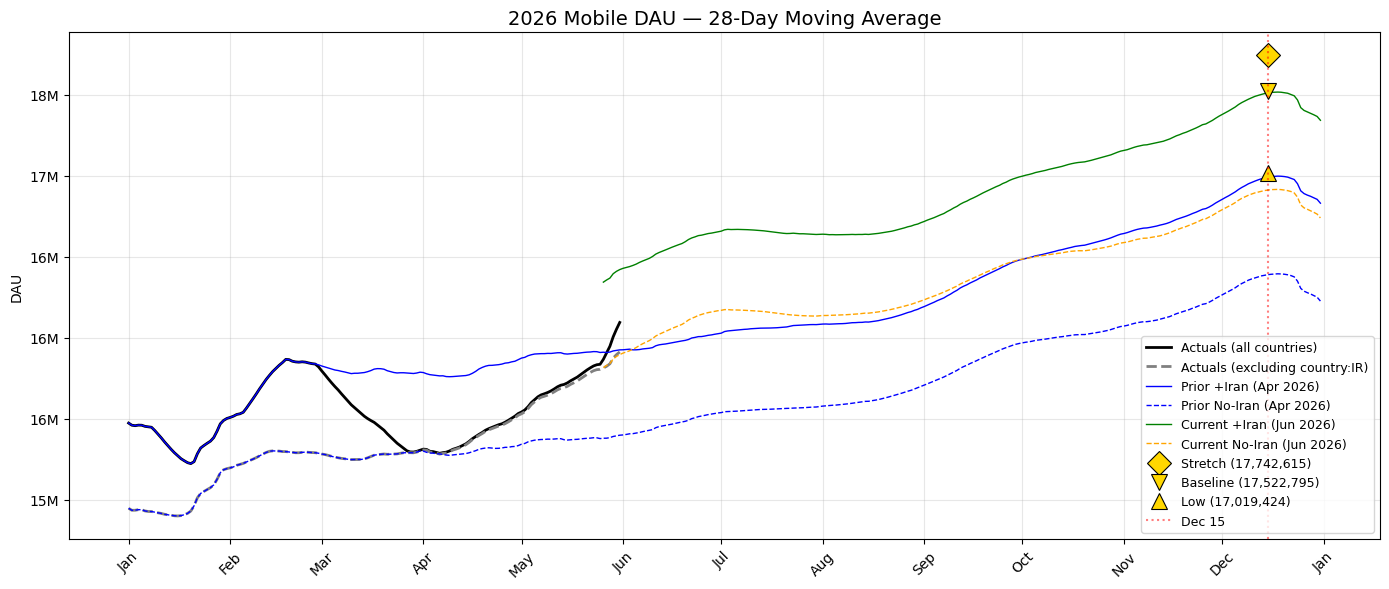

In [28]:
# [plot-mobile]
# Stakeholder Dec-15 mobile benchmarks (from data-official/2026-06/stakeholder_scenarios/data/stakeholder_targets.json)
STAKEHOLDER_MOBILE_LOW = 17_019_424
STAKEHOLDER_MOBILE_BASELINE = 17_522_795
STAKEHOLDER_MOBILE_STRETCH = 17_742_615

def render_mobile_plot(*, show_april: bool, title: str):
    fig, ax = plt.subplots(figsize=(14, 6))
    # Actuals (bold)
    ax.plot(clip_display(mobile_actual_all_ma), label="Actuals (all countries)",
            color="black", linewidth=2)
    ax.plot(clip_display(mobile_actual_no_iran_ma), label="Actuals (excluding country:IR)",
            color="gray", linewidth=2, linestyle="--")
    # April forecasts (blue) — only when show_april
    if show_april:
        ax.plot(clip_display(prev_mobile_plus_iran_ma), label="Prior +Iran (Apr 2026)",
                color="blue", linewidth=1)
        ax.plot(clip_display(prev_mobile_no_iran_ma), label="Prior No-Iran (Apr 2026)",
                color="blue", linewidth=1, linestyle="--")
    # June (current) forecasts
    ax.plot(clip_forecast_only(mobile_plus_iran_ma), label="Current +Iran (Jun 2026)",
            color="green", linewidth=1)
    ax.plot(clip_forecast_only(mobile_no_iran_ma), label="Current No-Iran (Jun 2026)",
            color="orange", linewidth=1, linestyle="--")
    # Stakeholder markers — stretch=diamond, base=down-triangle, low=up-triangle
    for value, marker, label in [
        (STAKEHOLDER_MOBILE_STRETCH, "D", "Stretch"),
        (STAKEHOLDER_MOBILE_BASELINE, "v", "Baseline"),
        (STAKEHOLDER_MOBILE_LOW, "^", "Low"),
    ]:
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
                markersize=12, markeredgecolor="black", markeredgewidth=0.8,
                linestyle="None", label=f"{label} ({value:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

render_mobile_plot(show_april=True,
                   title="2026 Mobile DAU — 28-Day Moving Average")


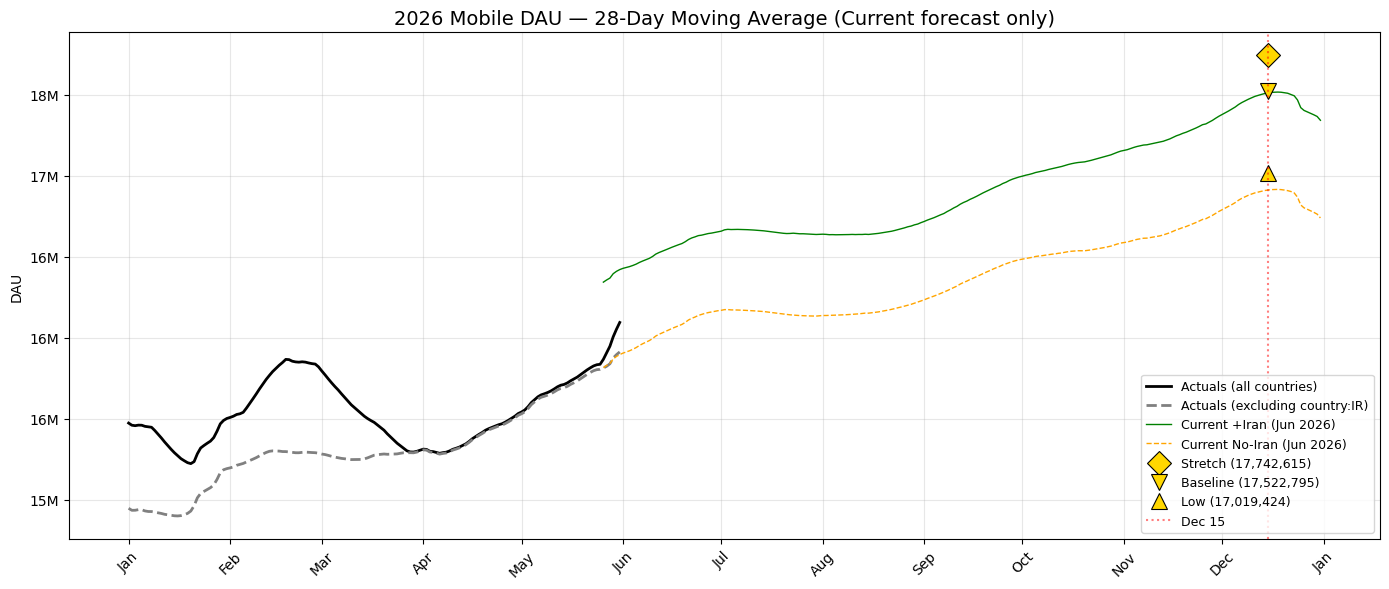

In [29]:
# [plot-mobile-no-april]
render_mobile_plot(show_april=False,
                   title="2026 Mobile DAU — 28-Day Moving Average (Current forecast only)")


In [30]:
# [mobile-dec15]
mobile_series = {
    "Actuals (all countries)": mobile_actual_all_ma,
    "Actuals (excl IR)": mobile_actual_no_iran_ma,
    "Prior +Iran (Apr 2026)": prev_mobile_plus_iran_ma,
    "Prior No-Iran (Apr 2026)": prev_mobile_no_iran_ma,
    "Current +Iran (Jun 2026)": mobile_plus_iran_ma,
    "Current No-Iran (Jun 2026)": mobile_no_iran_ma,
}

header = f"{'Series':<28s} {'Dec 15 28-day MA':>18s}"
print(header)
print("-" * len(header))
for name, s in mobile_series.items():
    val = s.get(MEASUREMENT_DATE, np.nan)
    val_str = f"{val:>15,.0f}" if pd.notna(val) else f"{'N/A':>15s}"
    print(f"{name:<28s} {val_str:>18s}")


Series                         Dec 15 28-day MA
-----------------------------------------------
Actuals (all countries)                     N/A
Actuals (excl IR)                           N/A
Prior +Iran (Apr 2026)               16,991,373
Prior No-Iran (Apr 2026)             16,389,749
Current +Iran (Jun 2026)             17,511,100
Current No-Iran (Jun 2026)           16,911,773


In [31]:
# [june-vs-targets]
# Compare each June forecast's Dec-15 28dMA against the stakeholder
# low / baseline / stretch targets. Gap = forecast - target (positive => forecast
# exceeds the target). Desktop and Mobile each use their own platform targets;
# the +Iran / no-Iran split shares the same target within a platform.
forecast_rows = [
    ("Desktop no-Iran", desktop_no_iran_ma.get(MEASUREMENT_DATE, np.nan),
     STAKEHOLDER_DESKTOP_LOW, STAKEHOLDER_DESKTOP_BASELINE, STAKEHOLDER_DESKTOP_STRETCH),
    ("Desktop +Iran", desktop_plus_iran_ma.get(MEASUREMENT_DATE, np.nan),
     STAKEHOLDER_DESKTOP_LOW, STAKEHOLDER_DESKTOP_BASELINE, STAKEHOLDER_DESKTOP_STRETCH),
    ("Mobile no-Iran", mobile_no_iran_ma.get(MEASUREMENT_DATE, np.nan),
     STAKEHOLDER_MOBILE_LOW, STAKEHOLDER_MOBILE_BASELINE, STAKEHOLDER_MOBILE_STRETCH),
    ("Mobile +Iran", mobile_plus_iran_ma.get(MEASUREMENT_DATE, np.nan),
     STAKEHOLDER_MOBILE_LOW, STAKEHOLDER_MOBILE_BASELINE, STAKEHOLDER_MOBILE_STRETCH),
]

def target_cell(forecast_value, target):
    """Render a target with the forecast's gap to it, e.g. '49,513,157 (-2,620,045)'."""
    return f"{target:,.0f} ({forecast_value - target:+,.0f})"

label_w = max(len(name) for name, *_ in forecast_rows)
fc_w = max(len("Forecast"), max(len(f"{fc:,.0f}") for _, fc, *_ in forecast_rows))
gap_w = max(
    len("Stretch (gap)"),
    max(len(target_cell(fc, t)) for _, fc, *targets in forecast_rows for t in targets),
)

print("June 2026 forecast vs stakeholder targets — Dec 15, 2026 28-day MA")
print("(gap = forecast - target; positive => forecast above target)")
print()
header = (f"{'Series':<{label_w}}  {'Forecast':>{fc_w}}  "
          f"{'Low (gap)':>{gap_w}}  {'Baseline (gap)':>{gap_w}}  {'Stretch (gap)':>{gap_w}}")
print(header)
print("-" * len(header))
for name, fc, low, base, stretch in forecast_rows:
    print(f"{name:<{label_w}}  {fc:>{fc_w},.0f}  "
          f"{target_cell(fc, low):>{gap_w}}  {target_cell(fc, base):>{gap_w}}  "
          f"{target_cell(fc, stretch):>{gap_w}}")


June 2026 forecast vs stakeholder targets — Dec 15, 2026 28-day MA
(gap = forecast - target; positive => forecast above target)

Series             Forecast                Low (gap)           Baseline (gap)            Stretch (gap)
------------------------------------------------------------------------------------------------------
Desktop no-Iran  46,893,112  49,039,852 (-2,146,740)  49,513,157 (-2,620,045)  49,772,388 (-2,879,276)
Desktop +Iran    47,834,362  49,039,852 (-1,205,490)  49,513,157 (-1,678,795)  49,772,388 (-1,938,026)
Mobile no-Iran   16,911,773    17,019,424 (-107,651)    17,522,795 (-611,022)    17,742,615 (-830,842)
Mobile +Iran     17,511,100    17,019,424 (+491,676)     17,522,795 (-11,695)    17,742,615 (-231,515)


In [32]:
# [slack-summary]
# Slack-friendly Dec-15 28dMA table for the June forecast only.
# Wrap the printed block in triple backticks when pasting into Slack so
# the column alignment survives.
rows = [
    ("Desktop no-Iran", desktop_no_iran_ma.get(MEASUREMENT_DATE, np.nan)),
    ("Desktop +Iran",   desktop_plus_iran_ma.get(MEASUREMENT_DATE, np.nan)),
    ("Mobile no-Iran",  mobile_no_iran_ma.get(MEASUREMENT_DATE, np.nan)),
    ("Mobile +Iran",    mobile_plus_iran_ma.get(MEASUREMENT_DATE, np.nan)),
]

label_width = max(len(name) for name, _ in rows)
value_width = max(len(f"{val:,.0f}") for _, val in rows)

print(f"June 2026 forecast — Dec 15, 2026 28-day MA")
print(f"{'Series':<{label_width}}  {'DAU':>{value_width}}")
print(f"{'-' * label_width}  {'-' * value_width}")
for name, val in rows:
    print(f"{name:<{label_width}}  {val:>{value_width},.0f}")


June 2026 forecast — Dec 15, 2026 28-day MA
Series                  DAU
---------------  ----------
Desktop no-Iran  46,893,112
Desktop +Iran    47,834,362
Mobile no-Iran   16,911,773
Mobile +Iran     17,511,100


In [33]:
# [slack-summary-compare]
# Side-by-side June vs April Dec-15 28dMA table for Slack.
rows = [
    ("Desktop no-Iran", desktop_no_iran_ma.get(MEASUREMENT_DATE, np.nan),
     prev_desktop_no_iran_ma.get(MEASUREMENT_DATE, np.nan)),
    ("Desktop +Iran",   desktop_plus_iran_ma.get(MEASUREMENT_DATE, np.nan),
     prev_desktop_plus_iran_ma.get(MEASUREMENT_DATE, np.nan)),
    ("Mobile no-Iran",  mobile_no_iran_ma.get(MEASUREMENT_DATE, np.nan),
     prev_mobile_no_iran_ma.get(MEASUREMENT_DATE, np.nan)),
    ("Mobile +Iran",    mobile_plus_iran_ma.get(MEASUREMENT_DATE, np.nan),
     prev_mobile_plus_iran_ma.get(MEASUREMENT_DATE, np.nan)),
]

label_width = max(len(name) for name, _, _ in rows)
june_col = "June-forecast DAU"
april_col = "April-forecast DAU"
june_width = max(len(june_col), max(len(f"{v:,.0f}") for _, v, _ in rows))
april_width = max(len(april_col), max(len(f"{v:,.0f}") for _, _, v in rows))

print(f"Dec 15, 2026 28-day MA")
print(f"{'Series':<{label_width}}  {june_col:>{june_width}}  {april_col:>{april_width}}")
print(f"{'-' * label_width}  {'-' * june_width}  {'-' * april_width}")
for name, june_val, april_val in rows:
    print(f"{name:<{label_width}}  {june_val:>{june_width},.0f}  {april_val:>{april_width},.0f}")


Dec 15, 2026 28-day MA
Series           June-forecast DAU  April-forecast DAU
---------------  -----------------  ------------------
Desktop no-Iran         46,893,112          46,891,136
Desktop +Iran           47,834,362          47,832,386
Mobile no-Iran          16,911,773          16,389,749
Mobile +Iran            17,511,100          16,991,373
